## **Question 1** 
**Generate spikes for 10 s (or longer if you want better statistics) using
a Poisson spike generator with a constant rate of 100 Hz, and record
their times of occurrence. Compute the coefficient of variation of the
interspike intervals, and the Fano factor for spike counts obtained
over counting intervals ranging from 1 to 100 ms. Plot the interspike
interval histogram.**

### Generating the Poisson Spike Sequence
A Poisson spike sequence is generated with the following formula: $$\Delta t = \frac{-\ln{x_{rand}}}{r} \tag{eq 1}$$ where "r" is the rate of the underlying distribution.

In [2]:
###Importing libraries###
import numpy as np
import matplotlib.pyplot as plt

###Setting variables###
r = 100.0 #underlying rate of distribution, in Hertz
times = [0.0] #list of time values, each corresponding to a spike
T = 10.0 #length of spike sequence generated, in seconds

###Creating list of spikes###
def find_delta_t(x_rand, rate):
    return -1*(np.log(x_rand)) / rate #finding delta_t according to (eq 1)

while times[-1] <= T: #Limiting the spike sequence to a certain time limit, defined by "T"
    #creating a spike at the previous time + delta_t
    times.append(times[-1] + find_delta_t(np.random.rand(), r)) 

#deleting the 0.0 at the start of the array and the last value, which is past T seconds
times = times[1:-1] 

### Plotting the Interspike Interval Histogram

Text(0, 0.5, 'Count')

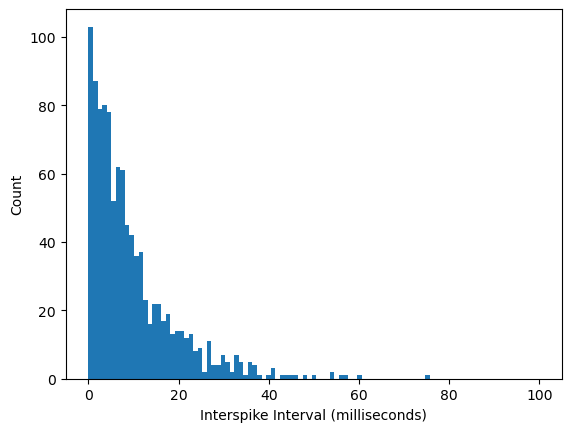

In [5]:
ISI = [] #creating an empty array for the interspike intervals

#iterating through every spike to calculate the time to the next spike
for i in np.arange(len(times) - 1):
    ISI.append((times[i + 1] - times[i]) * 1000) #multiplying by 1000 to convert from s to ms


plt.hist(ISI, bins=99, range=(0,100))
plt.xlabel("Interspike Interval (milliseconds)")
plt.ylabel("Count")

### Calculating Coefficient of Variation & Fano Factor
Coefficient of variation of a Poisson process is calculated via the standard deviation divided by the mean of the interspike interval distribution. \
\
Fano factor of a Poisson process is calculated via the variance divided by the mean of the spike count distribution. \
\
Thus, for any renewal process, the Fano factor should approach the square of the coefficient of variation.

In [10]:
C_v = np.std(ISI) / np.mean(ISI) #Calculating coefficient of variation

#Calculating Fano factor
bin_size = 0.001  # 1 ms bins
bins = np.arange(0, T + bin_size, bin_size)
counts, _ = np.histogram(times, bins=bins)
fano = np.var(counts) / np.mean(counts)

#Printing descriptive statistics
print(f"Coefficient of variation: {C_v}")
print(f"Fano Factor: {fano}")

Coefficient of variation: 0.9986440723672892
Fano Factor: 1.003895957651588
